# Set Covering Problem — Constructive Heuristics and Iterative Improvement
### Exercise 1.1 / 1.2 — CH1, CH2, CH3, redundancy elimination, FI and BI local search

This notebook builds three constructive heuristics (CH1 random, CH2 greedy cost/gain, CH3 regret), applies redundancy elimination (RE), and then implements two iterative improvement algorithms — first-improvement (FI) and best-improvement (BI) — for the SCP.

### The notebook covers:
1. Instance reading, incremental solution state and best-known solutions (BKS).
2. Constructive heuristics CH1, CH2, CH3 and RE (CH1+RE is RE applied to the CH1 solution).
3. Two local-search neighborhoods: **1-1 swap + RE** and **remove one set + greedy repair + RE**; FI and BI for each.
4. 16 experiments per instance (4 starting solutions × FI/BI × 2 neighborhoods). The 8 required ones use the swap neighborhood.
5. Results: average % deviation from BKS, total computation time, fraction of instances improved by local search, plots and interpretation.

## 1. Imports and configuration

`DATA_DIR` is relative to the notebook's current working directory. The data is in the `SCP-Instances/`, in the same directory.

In [22]:
import heapq
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("SCP-Instances")
SEED = 42


## 2. OR-Library SCP format

Each instance has the form

```text
m n
c_1 ... c_n
k_1 <k_1 column indices>
...
k_m <k_m column indices>
```

Here `m` is the number of elements (rows) and `n` is the number of available sets (columns). The file uses **1-based** column indices; the implementation converts them to **0-based** indices.

In [23]:
def read_scp_instance(filepath):
    """Read one SCP instance in OR-Library format.

    Format:
        m n
        c_1 ... c_n
        k_1 <k_1 column indices (1-based)>
        ...
        k_m <k_m column indices (1-based)>

    Returns dict containing m, n, costs array, rows list, and cols list.
    """
    filepath = Path(filepath)
    tokens = filepath.read_text().split()
    if len(tokens) < 2:
        raise ValueError(f"{filepath}: file is too short to contain m and n")

    values = [int(x) for x in tokens]
    idx = 0
    m, n = values[idx], values[idx + 1]
    idx += 2

    if m <= 0 or n <= 0:
        raise ValueError(f"{filepath}: invalid dimensions m={m}, n={n}")

    costs = np.asarray(values[idx : idx + n], dtype=float)
    idx += n

    rows = []
    for e in range(m):
        k = values[idx]
        idx += 1
        covering = [c - 1 for c in values[idx : idx + k]]  # Convert to 0-based
        idx += k
        rows.append(covering)

    cols = [[] for _ in range(n)]
    for e, covering in enumerate(rows):
        for j in covering:
            cols[j].append(e)

    return {"m": m, "n": n, "costs": costs, "rows": rows, "cols": cols}


## 3. Incremental solution state

The central idea is to avoid repeatedly recomputing coverage from scratch. For a partial solution we maintain:

| State | Meaning | Update/query | 
|---|---|---|
| `chosen[j]` | set `j` is selected | O(1) lookup | 
| `cover_count[e]` | number of selected sets covering element `e` | updated only when a set is added/removed | 
| `uncovered` + `_pos` | current uncovered elements | O(1) swap-remove/append | 
| `gain[j]` | number of currently uncovered elements that set `j` would cover | maintained incrementally | 
| `solution_cost` | total cost of selected sets | O(1) update | 

The key candidate condition is `gain[j] > 0`. Therefore a redundant set (`gain == 0`) is never selected during construction.

When an element changes from uncovered to covered, every set containing that element loses one unit of gain. During RE, the reverse update restores that gain if the element becomes uncovered again.

In [24]:
class SCPInstance:
    """Maintains incremental solution state for Set Covering Problem.

    State variables maintained in O(1) / O(k):
    - chosen: boolean mask of selected sets
    - cover_count: number of selected sets covering element e
    - gain: number of uncovered elements covered by set j
    - uncovered & _pos: O(1) list for fast sampling and state maintenance
    - solution_cost: total cost of currently chosen sets
    """

    def __init__(self, data, name=None):
        self.name = name
        self.m, self.n = data["m"], data["n"]
        self.costs = np.asarray(data["costs"], dtype=float)
        self.rows = data["rows"] # element -> covering sets (lists)
        self.cols = data["cols"]  # set -> covered elements (lists)
        self.rows_np = [np.asarray(r, dtype=np.int64) for r in self.rows]
        self.cols_np = [np.asarray(c, dtype=np.int64) for c in self.cols]
        self.col_size = np.asarray([len(c) for c in self.cols], dtype=np.int64)
        self.reset()

    # ---------------------------------------------------------------- state
    def reset(self):
        self.chosen = np.zeros(self.n, dtype=bool)
        self.cover_count = np.zeros(self.m, dtype=np.int64)
        self.gain = self.col_size.copy()    # nothing covered yet -> gain = column size
        self.uncovered = list(range(self.m))  # list of uncovered elements
        self._pos = np.arange(self.m, dtype=np.int64) # position of each element inside `uncovered`
        self.solution_cost = 0.0

    def snapshot(self):
        """Return a deep copy snapshot of current state."""
        return {
            "chosen": self.chosen.copy(),
            "cover_count": self.cover_count.copy(),
            "gain": self.gain.copy(),
            "uncovered": self.uncovered.copy(),
            "_pos": self._pos.copy(),
            "solution_cost": float(self.solution_cost),
        }

    def restore(self, state):
        """Restore instance state from a snapshot."""
        self.chosen = state["chosen"].copy()
        self.cover_count = state["cover_count"].copy()
        self.gain = state["gain"].copy()
        self.uncovered = state["uncovered"].copy()
        self._pos = state["_pos"].copy()
        self.solution_cost = float(state["solution_cost"])

    def is_complete_cover(self):
        return len(self.uncovered) == 0

    def solution_sets(self):
        return np.flatnonzero(self.chosen).tolist()
    
    # ------------------------------------------------ O(1) uncovered-list ops
    def _mark_covered(self, e):
        pos = int(self._pos[e])
        last = self.uncovered.pop()
        if last != e:
            self.uncovered[pos] = last
            self._pos[last] = pos
        self.gain[self.rows_np[e]] -= 1

    def _mark_uncovered(self, e):
        self._pos[e] = len(self.uncovered)
        self.uncovered.append(e)
        self.gain[self.rows_np[e]] += 1

    # ------------------------------------------------------------ mutations
    def add_set(self, j):
        j = int(j)
        if self.chosen[j]:
            return 0
        self.chosen[j] = True
        self.solution_cost += self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] += 1
        newly_covered = els[self.cover_count[els] == 1]
        for e in newly_covered:
            self._mark_covered(int(e))
        return len(newly_covered)

    def remove_set(self, j):
        j = int(j)
        if not self.chosen[j]:
            return 0
        self.chosen[j] = False
        self.solution_cost -= self.costs[j]

        els = self.cols_np[j]
        self.cover_count[els] -= 1
        newly_uncovered = els[self.cover_count[els] == 0]
        for e in newly_uncovered:
            self._mark_uncovered(int(e))
        return len(newly_uncovered)
    
    # -------------------------------------------------------------- queries
    def is_removable(self, j):
        """A set is removable if all its covered elements are covered by >= 2 sets."""
        return bool(np.all(self.cover_count[self.cols_np[int(j)]] > 1))
    
    # -------------------------------------------------------- verification
    def check_solution(self):
        """Verify feasibility and cost correctness."""
        covered = np.zeros(self.m, dtype=bool)
        for j in np.flatnonzero(self.chosen):
            covered[self.cols_np[j]] = True
        if not covered.all():
            raise AssertionError(f"{self.name}: incomplete set cover")
        if not np.isclose(self.solution_cost, self.costs[self.chosen].sum()):
            raise AssertionError(f"{self.name}: cost mismatch")

## 4. Instance loading and best-known solutions

The filename convention used here maps names such as `scp42.txt` to instance label `4.2`, and `scpA3.txt` to `A.3`. Duplicate labels are rejected rather than silently overwritten.

The Best Known Solution (BKS) dictionary is kept separate from the heuristic code so that the percentage-deviation calculation is easy to audit.

In [25]:
FNAME_RE = re.compile(r"scp([A-Za-z]|\d)(\d+)", re.IGNORECASE)

def label_from_filename(path):
    match = FNAME_RE.search(Path(path).name)
    if not match:
        return None
    group, num = match.groups()
    return f"{group.upper()}.{num}"

def sort_key(label):
    cls, num = label.split(".")
    return (cls, int(num))

def load_all_instances(data_dir):
    data_dir = Path(data_dir)
    if not data_dir.exists():
        return {}

    instances = {}
    for path in sorted(data_dir.iterdir()):
        if not path.is_file():
            continue
        label = label_from_filename(path)
        if label is None:
            continue
        if label in instances:
            raise ValueError(f"Duplicate instance label {label!r}: multiple files match it")
        instances[label] = SCPInstance(read_scp_instance(path), name=label)

    return dict(sorted(instances.items(), key=lambda kv: sort_key(kv[0])))

BKS = {
    "4.2": 512, "4.3": 516, "4.4": 494, "4.5": 512,
    "4.6": 560, "4.7": 430, "4.8": 492, "4.9": 641, 
    "5.1": 253, "5.2": 302, "5.3": 226, "5.4": 242, "5.5": 211,
    "5.6": 213, "5.7": 293, "5.8": 288, "5.9": 279, 
    "6.1": 138, "6.2": 146, "6.3": 145, "6.4": 131, "6.5": 161,
    "A.1": 253, "A.2": 252, "A.3": 232, "A.4": 234, "A.5": 236,
    "B.1": 69,  "B.2": 76,  "B.3": 80,  "B.4": 79,  "B.5": 72,
    "C.1": 227, "C.2": 219, "C.3": 243, "C.4": 219, "C.5": 215,
    "D.1": 60, "D.2": 66, "D.3": 72, "D.4": 62, "D.5": 61,
}

instances = load_all_instances(DATA_DIR)
if not instances:
    print(f"No SCP instances found in {DATA_DIR.resolve()}. Add the Moodle files and rerun this section.")
else:
    missing_bks = sorted(set(instances) - set(BKS), key=sort_key)
    if missing_bks:
        raise ValueError(f"Missing BKS values for: {missing_bks}")
    print(f"Loaded {len(instances)} instance(s): {list(instances)}")
    not_found = sorted(set(BKS) - set(instances), key=sort_key)
    if not_found:
        print(f"WARNING: no file found for {len(not_found)} instance(s) listed in BKS: {not_found}. "
              "Check the data folder / file names (the standard benchmark has 45 instances).")

Loaded 42 instance(s): ['4.2', '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5.1', '5.2', '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6.1', '6.2', '6.3', '6.4', '6.5', 'A.1', 'A.2', 'A.3', 'A.4', 'A.5', 'B.1', 'B.2', 'B.3', 'B.4', 'B.5', 'C.1', 'C.2', 'C.3', 'C.4', 'C.5', 'D.1', 'D.2', 'D.3', 'D.4', 'D.5']


## 5. Constructive algorithms (CH1, CH2 and CH3)

In [26]:
def ch1_random(inst, seed=SEED):
    """CH1: random uncovered element + random set covering it."""
    rnd = random.Random(seed)
    inst.reset()
    while not inst.is_complete_cover():
        e = rnd.choice(inst.uncovered)
        j = rnd.choice(inst.rows[e])
        inst.add_set(j)
    return inst.solution_cost


def ch2_greedy(inst):
    """CH2: dynamic minimum cost/gain, implemented with a lazy heap."""
    inst.reset()
    costs = inst.costs

    heap = [
        (float(costs[j] / inst.gain[j]), j)
        for j in range(inst.n)
        if inst.gain[j] > 0
    ]
    heapq.heapify(heap)

    while not inst.is_complete_cover():
        # Lazy deletion: heap entries become stale when a set's gain changes.
        while heap:
            ratio, j = heapq.heappop(heap)
            if inst.chosen[j] or inst.gain[j] <= 0:
                continue
            current_ratio = float(costs[j] / inst.gain[j])
            if ratio == current_ratio:
                break
        else:
            raise RuntimeError(f"{inst.name}: no positive-gain candidate remains")

        # These elements are the only ones whose coverage/gain will change.
        els = inst.cols_np[j]
        newly_covered = els[inst.cover_count[els] == 0]
        inst.add_set(j)

        # Every set containing a newly covered element has had its gain reduced.
        touched = set()
        for e in newly_covered:
            touched.update(int(s) for s in inst.rows_np[int(e)])

        for s in touched:
            if not inst.chosen[s] and inst.gain[s] > 0:
                heapq.heappush(heap, (float(costs[s] / inst.gain[s]), s))

    return inst.solution_cost


def compute_regret(inst):
    """Return one static regret value per element."""
    regret = np.empty(inst.m, dtype=float)
    for e, covering_sets in enumerate(inst.rows_np):
        costs = inst.costs[covering_sets]
        if len(costs) < 2:
            regret[e] = np.inf
        else:
            two_smallest = np.partition(costs, 1)[:2]
            regret[e] = float(two_smallest[1] - two_smallest[0])
    return regret


def ch3_regret(inst, regret=None):
    """CH3: process elements by decreasing regret; choose best current cost/gain set."""
    if regret is None:
        regret = compute_regret(inst)

    inst.reset()
    order = np.argsort(-regret, kind="stable")
    for e in order:
        if inst.cover_count[e] > 0:
            continue
        cand = inst.rows_np[e]
        scores = inst.costs[cand] / inst.gain[cand]
        j = cand[int(np.argmin(scores))]
        inst.add_set(j)

    return inst.solution_cost


HEURISTICS = {
    "CH1 (random)": ch1_random,
    "CH2 (cost/gain)": ch2_greedy,
    "CH3 (regret)": ch3_regret,
}


## 6. Redundancy elimination (RE)

In [27]:
RE_ORDERS = ["cost_desc", "random", "cost_per_element"]

def redundancy_elimination(inst, order="cost_desc", seed=SEED):
    """Remove redundant selected sets once, in the requested order."""
    if not inst.is_complete_cover():
        raise ValueError("RE must start from a complete cover")

    sets = inst.solution_sets()
    if order == "cost_desc":
        sets.sort(key=lambda j: (-inst.costs[j], j))
    elif order == "random":
        random.Random(seed).shuffle(sets)
    elif order == "cost_per_element":
        sets.sort(
            key=lambda j: (
                -(inst.costs[j] / len(inst.cols_np[j]) if len(inst.cols_np[j]) else np.inf),
                j,
            )
        )
    else:
        raise ValueError(f"Unknown RE order: {order}")

    for j in sets:
        if inst.is_removable(j):
            inst.remove_set(j)

    return inst.solution_cost


## 7. Construction of initial solution

We'll construct one initial solution for all the methods CH1, CH2, CH3, and CH1+RE.  

In [28]:
def generate_initial_solutions(instances, bks_dict):
    """Generate the 4 required initial solutions (CH1, CH2, CH3, CH1+RE) for each
    instance. Each entry is (cost, snapshot, construction_time_s).

    CH1+RE is obtained by applying RE to the *same* CH1 solution, so CH1 and
    CH1+RE differ only by the RE step. Construction times are recorded so that
    total computation time (construction + local search) can be reported.
    """
    prepared_instances = {}

    for label, inst in instances.items():
        if label not in bks_dict:
            print(f"Skipping {label}: No BKS found.")
            continue

        instance_states = {}

        t0 = time.perf_counter()
        precomputed_regret = compute_regret(inst)
        regret_time = time.perf_counter() - t0

        for method, construct in HEURISTICS.items():
            if "CH1" in method:
                t0 = time.perf_counter()
                cost_ch1 = construct(inst, seed=SEED)
                t_ch1 = time.perf_counter() - t0
                instance_states["CH1"] = (cost_ch1, inst.snapshot(), t_ch1)

                # RE applied to that very same CH1 solution
                t0 = time.perf_counter()
                cost_ch1_re = redundancy_elimination(inst, order="cost_desc", seed=SEED)
                t_re = time.perf_counter() - t0
                instance_states["CH1+RE"] = (cost_ch1_re, inst.snapshot(), t_ch1 + t_re)

            elif "CH3" in method:
                t0 = time.perf_counter()
                cost_ch3 = construct(inst, regret=precomputed_regret)
                t_ch3 = time.perf_counter() - t0 + regret_time
                instance_states["CH3"] = (cost_ch3, inst.snapshot(), t_ch3)

            else:  # CH2
                t0 = time.perf_counter()
                cost_ch2 = construct(inst)
                t_ch2 = time.perf_counter() - t0
                instance_states["CH2"] = (cost_ch2, inst.snapshot(), t_ch2)

        prepared_instances[label] = instance_states

    return prepared_instances


if instances:
    initial_solutions_data = generate_initial_solutions(instances, BKS)
    print(f"Successfully generated 4 initial solutions for {len(initial_solutions_data)} instances.")
else:
    print("Real experiment skipped: no SCP instance files were found.")

Successfully generated 4 initial solutions for 42 instances.


## 8. Iterative improvement: two neighborhoods, FI and BI

We compare two local-search neighborhoods. **RE is applied after every accepted move** (it is part of the move). The starting solution is used as it is: there is no RE before the first move, so CH1 and CH1+RE remain genuinely different starting points.

### Neighborhood N1: 1–1 swap + RE
Choose a selected set `i` and an unselected set `k`. The swap is feasible when `k` covers every **critical element** of `i` (an element covered only by `i`). After the swap, RE removes any selected set that has become redundant (one entering set can make several sets redundant).

### Neighborhood N2: remove one set + greedy repair + RE
Choose a selected set `i` and remove it. The elements it alone covered become uncovered; they are re-covered greedily by repeatedly adding the set with minimum `cost / (newly covered elements)` (set `i` may not re-enter). The repair can add **several** sets, so this is a different kind of move from a swap. RE is then applied. N2 has only |S| neighbors, so scanning it is cheap.

### Exact evaluation
Both neighborhoods are evaluated exactly, including RE, **before** a move is accepted: a move is accepted only if the final cost after RE is strictly lower than the current cost. (Predicting the effect of RE analytically can be wrong when two sets are individually redundant but not jointly removable; here the swap neighborhood uses the analytical prediction only as a lower bound to skip hopeless candidates and then re-evaluates exactly.) The search therefore always terminates in a local optimum.

### Speed
Swap moves are evaluated for all candidate sets at once with one matrix product, and FI is a *true* first improvement: it scans a random permutation lazily in chunks and stops at the first improving move, instead of building the whole neighborhood.

FI and BI receive exactly the same saved starting snapshot per instance/heuristic. A fixed seed randomizes FI's scan order reproducibly. No time limit is used, so both algorithms end in a local optimum.

In [29]:
import time
import numpy as np

EPS = 1e-9

# ----------------------------------------------------------------------------
# Matrices used to evaluate a whole neighborhood at once (one BLAS call)
# ----------------------------------------------------------------------------
def build_matrices(inst):
    """A[k, e] = 1 iff set k covers element e; AT is A transposed (contiguous).
    Built once per instance, outside the timed local-search phase."""
    A = np.zeros((inst.n, inst.m), dtype=np.float32)
    for j in range(inst.n):
        A[j, inst.cols_np[j]] = 1.0
    return A, np.ascontiguousarray(A.T)


def _critical_matrix(inst):
    """Selected sets, their critical-element matrix C (|S| x m) and |crit| per set.
    An element is critical for s if s is the only selected set covering it."""
    sel = np.flatnonzero(inst.chosen)
    C = np.zeros((len(sel), inst.m), dtype=np.float32)
    for r, s in enumerate(sel):
        els = inst.cols_np[s]
        C[r, els[inst.cover_count[els] == 1]] = 1.0
    return sel, C, C.sum(axis=1)


def _re_simulate(inst, cc, candidates):
    """Redundancy elimination on a copy of the cover counts `cc` (modified in place).

    Uses exactly the order of `redundancy_elimination(order="cost_desc")`:
    most expensive first, ties by index. Only `candidates` are tested; a selected
    set with a critical element that the move does not cover can never become
    removable, so restricting to candidates gives the same result as a full RE.
    Returns the list of sets removed.
    """
    removed = []
    for s in sorted(candidates, key=lambda s: (-inst.costs[s], s)):
        els = inst.cols_np[s]
        if np.all(cc[els] > 1):
            cc[els] -= 1
            removed.append(int(s))
    return removed


def _move(cost, add, remove):
    return {"cost": float(cost), "add": add, "remove": remove}


# ----------------------------------------------------------------------------
# Neighborhood N1: 1-1 swap + RE
# ----------------------------------------------------------------------------
def _sim_swap(inst, i, k, removable_k):
    """Exact result of: remove i, add k, then RE. `removable_k` are the selected sets
    whose critical elements are all covered by k (the only RE candidates)."""
    cc = inst.cover_count.copy()
    cc[inst.cols_np[i]] -= 1
    cc[inst.cols_np[k]] += 1
    candidates = [int(s) for s in removable_k if s != i] + [k]
    removed = _re_simulate(inst, cc, candidates)
    cost = (inst.solution_cost - inst.costs[i] + inst.costs[k]
            - sum(inst.costs[s] for s in removed))
    return _move(cost, [k], [i] + removed)


def _swap_scan(inst, mats, mode, rng, chunk=256):
    """Return an improving 1-1 swap+RE move (FI: first found in a random scan,
    BI: best of the whole neighborhood) or None if the solution is a local optimum.

    Swap (i, k) is feasible iff k covers every critical element of i. For all
    candidate k at once, `A[k] @ C.T` counts how many critical elements of each
    selected set k covers; comparing with |crit| tells which sets k could replace.
    The resulting cost is an optimistic bound (RE may remove fewer sets than
    predicted), so every move is re-evaluated exactly before being accepted.
    """
    A, _ = mats
    sel, C, csize = _critical_matrix(inst)
    sel_cost = inst.costs[sel]
    has_crit = csize > 0.5   # a set without critical elements is redundant: RE removes it, it is never "swapped out"
    cur = inst.solution_cost
    unsel = np.flatnonzero(~inst.chosen)

    def predict(cand):
        covers_all = (A[cand] @ C.T) >= (csize - 0.5)
        pred = cur + inst.costs[cand] - covers_all.astype(np.float64) @ sel_cost
        return pred, covers_all

    if mode == "BI":
        pred, ca = predict(unsel)
        order = np.flatnonzero(pred < cur - EPS)
        order = order[np.argsort(pred[order], kind="stable")]
        best = None
        for t in order:
            if best is not None and pred[t] >= best["cost"] - EPS:
                break  # optimistic bound cannot beat the best exact move found
            k = int(unsel[t])
            R = sel[ca[t]]
            for i in sel[ca[t] & has_crit]:
                mv = _sim_swap(inst, int(i), k, R)
                if mv["cost"] < cur - EPS and (best is None or mv["cost"] < best["cost"] - EPS):
                    best = mv
        return best

    # FI: random scan order, evaluated lazily in chunks; stop at the first improving move
    perm = rng.permutation(unsel)
    for s0 in range(0, len(perm), chunk):
        cand = perm[s0:s0 + chunk]
        pred, ca = predict(cand)
        for t in np.flatnonzero(pred < cur - EPS):
            k = int(cand[t])
            R = sel[ca[t]]
            for i in sel[ca[t] & has_crit]:
                mv = _sim_swap(inst, int(i), k, R)
                if mv["cost"] < cur - EPS:
                    return mv
    return None


# ----------------------------------------------------------------------------
# Neighborhood N2: remove one set + greedy repair + RE
# ----------------------------------------------------------------------------
def _sim_remove_repair(inst, mats, sel, C, i):
    """Exact result of: remove selected set i; repeatedly add the set with minimum
    cost / (number of still-uncovered elements it covers) until everything is covered
    again (i itself may not re-enter); then RE. The repair can add several sets."""
    A, AT = mats
    cc = inst.cover_count.copy()
    els_i = inst.cols_np[i]
    cc[els_i] -= 1
    U = els_i[cc[els_i] == 0]          # elements left uncovered by the removal
    added = []
    while U.size:
        gains = AT[U].sum(axis=0)       # uncovered elements covered by each set
        gains[i] = 0.0
        pos = gains > 0
        if not pos.any():
            return None                 # cannot repair (should not happen)
        score = np.full(inst.n, np.inf)
        score[pos] = inst.costs[pos] / gains[pos]
        j = int(np.argmin(score))
        added.append(j)
        cc[inst.cols_np[j]] += 1
        U = U[cc[U] == 0]

    # RE candidates: selected sets whose critical elements are all covered by the added sets
    covered = A[added].max(axis=0) if added else np.zeros(inst.m, dtype=np.float32)
    ok = (C @ (1.0 - covered)) < 0.5
    candidates = [int(s) for s in sel[ok] if s != i] + added
    removed = _re_simulate(inst, cc, candidates)

    cost = (inst.solution_cost - inst.costs[i]
            + sum(inst.costs[j] for j in added)
            - sum(inst.costs[s] for s in removed))
    return _move(cost, added, [i] + removed)


def _remove_repair_scan(inst, mats, mode, rng):
    sel, C, _ = _critical_matrix(inst)
    cur = inst.solution_cost
    order = rng.permutation(sel) if mode == "FI" else sel
    best = None
    for i in order:
        mv = _sim_remove_repair(inst, mats, sel, C, int(i))
        if mv is None or mv["cost"] >= cur - EPS:
            continue
        if mode == "FI":
            return mv
        if best is None or mv["cost"] < best["cost"] - EPS:
            best = mv
    return best


# ----------------------------------------------------------------------------
# Iterative improvement driver
# ----------------------------------------------------------------------------
def local_search(inst, mats, method, neighborhood, seed=SEED):
    """FI / BI until no strictly improving move exists.

    No normalization of the start: the initial solution is used as it is (so CH1
    and CH1+RE remain different starting points). RE is applied after every
    accepted move, as part of the move. Every move has been evaluated exactly, so
    the cost strictly decreases and the search terminates.
    """
    if method not in ("FI", "BI"):
        raise ValueError("method must be 'FI' or 'BI'")
    if not inst.is_complete_cover():
        raise ValueError(f"{inst.name}: local search requires a feasible cover")

    rng = np.random.default_rng(seed)
    moves = 0
    while True:
        if neighborhood == "swap":
            mv = _swap_scan(inst, mats, method, rng)
        elif neighborhood == "remove_repair":
            mv = _remove_repair_scan(inst, mats, method, rng)
        else:
            raise ValueError("neighborhood must be 'swap' or 'remove_repair'")
        if mv is None:
            break

        before = inst.solution_cost
        for s in mv["add"]:
            inst.add_set(s)
        for s in mv["remove"]:
            inst.remove_set(s)
        if not np.isclose(inst.solution_cost, mv["cost"]) or inst.solution_cost >= before - EPS:
            raise AssertionError(f"{inst.name}: move did not give the predicted improvement")
        moves += 1

    inst.check_solution()
    return {"cost": float(inst.solution_cost), "moves": moves}


def first_improvement(inst, mats, neighborhood="swap", seed=SEED):
    return local_search(inst, mats, "FI", neighborhood, seed)


def best_improvement(inst, mats, neighborhood="swap"):
    return local_search(inst, mats, "BI", neighborhood)


NEIGHBORHOODS = {
    "1-1 Swap + RE": "swap",
    "Remove + Greedy Repair + RE": "remove_repair",
}

## 9. Experimental design and execution

The assignment requires four initial solutions: CH1, CH2, CH3 and CH1+RE.

For the required experiment, each starting solution is paired with FI and BI using the **1–1 swap + RE** neighborhood (8 combinations). As an additional experiment the same four starts are paired with FI and BI using **remove + greedy repair + RE**.

For every instance and starting heuristic the same saved snapshot is restored before FI and BI, so differences between FI and BI are not caused by different starting points.

Reported times: the local-search time (matrix set-up per instance excluded, it is shared by all runs), the construction time of the starting solution, and their sum. For quick testing set `TEST_LABELS` to a few instance labels in the next cell. Results are written to the CSV after every instance.

In [30]:
START_HEURISTICS = ["CH1", "CH2", "CH3", "CH1+RE"]

# First the 8 required experiments (swap neighborhood), then the 8 additional ones.
CONFIGS = [
    (start, method, neighborhood)
    for neighborhood in NEIGHBORHOODS
    for start in START_HEURISTICS
    for method in ("FI", "BI")
]

SAVE_CSV = "scp_local_search_results.csv"


def run_experiments(instances, bks_dict, initial_solutions_data, seed=SEED, labels=None):
    """Run all 16 (start, method, neighborhood) combinations on every instance.
    `labels` restricts the run to a subset of instances (useful for a quick test).
    Results are saved after every instance so a long run is never lost."""
    records = []
    t_all = time.perf_counter()
    labels = list(instances) if labels is None else labels

    for label in labels:
        inst = instances[label]
        if label not in bks_dict or label not in initial_solutions_data:
            continue
        bks = float(bks_dict[label])
        mats = build_matrices(inst)          # one-off setup, not part of the timed phase

        for start_heuristic, ls_method, neighborhood_name in CONFIGS:
            init_cost, snapshot, constr_time = initial_solutions_data[label][start_heuristic]
            inst.restore(snapshot)           # identical start for FI and BI

            starting_cost = float(inst.solution_cost)
            if not np.isclose(starting_cost, init_cost):
                raise AssertionError(f"{label} / {start_heuristic}: snapshot cost mismatch")

            t0 = time.perf_counter()
            result = local_search(inst, mats, ls_method,
                                  NEIGHBORHOODS[neighborhood_name], seed=seed)
            elapsed = time.perf_counter() - t0

            final_cost = float(result["cost"])
            records.append({
                "Instance": label,
                "Start_Heuristic": start_heuristic,
                "LS_Method": ls_method,
                "Neighborhood": neighborhood_name,
                "Algorithm": f"{start_heuristic} + {ls_method} + {neighborhood_name}",
                "Init_Cost": starting_cost,
                "Final_Cost": final_cost,
                "BKS": bks,
                "Init_Pct_Dev": 100.0 * (starting_cost - bks) / bks,
                "Pct_Dev": 100.0 * (final_cost - bks) / bks,
                "Improved": final_cost < starting_cost - 1e-12,
                "Moves": int(result["moves"]),
                "Constr_Time_s": float(constr_time),
                "Time_s": elapsed,
            })

        pd.DataFrame(records).to_csv(SAVE_CSV, index=False)
        print(f"[{time.perf_counter() - t_all:7.1f}s] finished {label}", flush=True)

    return pd.DataFrame(records)


# Quick test first (a few instances), then set TEST_LABELS = None for the full run.
TEST_LABELS = None  

if instances and initial_solutions_data:
    df_detailed = run_experiments(instances, BKS, initial_solutions_data,
                                  seed=SEED, labels=TEST_LABELS)
    df_detailed.to_csv(SAVE_CSV, index=False)
    print(f"Completed {len(df_detailed)} experiment runs. Results saved to {SAVE_CSV}")
else:
    df_detailed = pd.DataFrame()
    print("Experiment skipped because SCP instances or initial solutions are unavailable.")

[    1.7s] finished 4.2
[    3.3s] finished 4.3
[    4.5s] finished 4.4
[    6.2s] finished 4.5
[    8.0s] finished 4.6
[    9.0s] finished 4.7
[   10.5s] finished 4.8
[   12.0s] finished 4.9
[   13.7s] finished 5.1
[   16.1s] finished 5.2
[   17.9s] finished 5.3
[   19.6s] finished 5.4
[   21.7s] finished 5.5
[   23.8s] finished 5.6
[   25.3s] finished 5.7
[   27.0s] finished 5.8
[   28.5s] finished 5.9
[   29.1s] finished 6.1
[   29.6s] finished 6.2
[   30.1s] finished 6.3
[   30.7s] finished 6.4
[   31.4s] finished 6.5
[   35.2s] finished A.1
[   39.6s] finished A.2
[   44.2s] finished A.3
[   47.9s] finished A.4
[   51.3s] finished A.5
[   53.1s] finished B.1
[   54.3s] finished B.2
[   55.3s] finished B.3
[   56.7s] finished B.4
[   57.8s] finished B.5
[   63.6s] finished C.1
[   68.6s] finished C.2
[   75.7s] finished C.3
[   82.6s] finished C.4
[   88.3s] finished C.5
[   89.6s] finished D.1
[   92.4s] finished D.2
[   94.7s] finished D.3
[   97.3s] finished D.4
[   99.6s] finis

## 10. Required results

The assignment asks for three aggregate measures for each experiment:

1. **Average percentage deviation from the BKS** (also shown before local search, `Avg_Init_Dev`)
2. **Total computation time across all instances** (local search, construction, and their sum)
3. **Fraction of instances that profit from local search** (final cost strictly lower than the starting cost)

The first table reports the required eight 1–1 swap experiments, the second the additional remove + greedy repair experiments.

In [31]:
def summarize_results(df, neighborhood=None):
    data = df if neighborhood is None else df[df["Neighborhood"] == neighborhood]
    if data.empty:
        return pd.DataFrame()

    summary = (
        data.groupby(["Start_Heuristic", "LS_Method", "Neighborhood"], sort=False)
        .agg(
            Avg_Init_Dev=("Init_Pct_Dev", "mean"),
            Avg_Pct_Dev=("Pct_Dev", "mean"),
            LS_Time_s=("Time_s", "sum"),
            Constr_Time_s=("Constr_Time_s", "sum"),
            Fraction_Improved=("Improved", "mean"),
            Avg_Moves=("Moves", "mean"),
        )
        .reset_index()
    )
    summary["Total_Time_s"] = summary["LS_Time_s"] + summary["Constr_Time_s"]
    summary["Fraction_Improved_pct"] = 100.0 * summary["Fraction_Improved"]
    summary["Algorithm"] = (
        summary["Start_Heuristic"] + " + " + summary["LS_Method"] + " + " + summary["Neighborhood"]
    )
    return summary[[
        "Algorithm", "Start_Heuristic", "LS_Method", "Neighborhood",
        "Avg_Init_Dev", "Avg_Pct_Dev", "LS_Time_s", "Constr_Time_s", "Total_Time_s",
        "Fraction_Improved_pct", "Avg_Moves",
    ]]


FMT = {
    "Avg_Init_Dev": "{:.2f}%",
    "Avg_Pct_Dev": "{:.2f}%",
    "LS_Time_s": "{:.3f}",
    "Constr_Time_s": "{:.3f}",
    "Total_Time_s": "{:.3f}",
    "Fraction_Improved_pct": "{:.1f}%",
    "Avg_Moves": "{:.1f}",
}

required_summary = summarize_results(df_detailed, "1-1 Swap + RE")
additional_summary = summarize_results(df_detailed, "Remove + Greedy Repair + RE")

print("REQUIRED EXPERIMENTS — 1-1 Swap + RE")
display(required_summary.style.format(FMT))

print("\nADDITIONAL EXPERIMENT — Remove + Greedy Repair + RE")
display(additional_summary.style.format(FMT))

REQUIRED EXPERIMENTS — 1-1 Swap + RE


,Algorithm,Start_Heuristic,LS_Method,Neighborhood,Avg_Init_Dev,Avg_Pct_Dev,LS_Time_s,Constr_Time_s,Total_Time_s,Fraction_Improved_pct,Avg_Moves
0,CH1 + FI + 1-1 Swap + RE,CH1,FI,1-1 Swap + RE,2096.61%,564.11%,5.163,0.094,5.257,100.0%,74.2
1,CH1 + BI + 1-1 Swap + RE,CH1,BI,1-1 Swap + RE,2096.61%,648.57%,17.604,0.094,17.699,100.0%,22.6
2,CH2 + FI + 1-1 Swap + RE,CH2,FI,1-1 Swap + RE,13.62%,4.72%,0.615,2.939,3.554,100.0%,4.2
3,CH2 + BI + 1-1 Swap + RE,CH2,BI,1-1 Swap + RE,13.62%,2.48%,0.848,2.939,3.788,100.0%,2.7
4,CH3 + FI + 1-1 Swap + RE,CH3,FI,1-1 Swap + RE,15.82%,8.83%,0.702,0.196,0.898,100.0%,5.0
5,CH3 + BI + 1-1 Swap + RE,CH3,BI,1-1 Swap + RE,15.82%,6.98%,0.747,0.196,0.943,100.0%,3.1
6,CH1+RE + FI + 1-1 Swap + RE,CH1+RE,FI,1-1 Swap + RE,1592.64%,583.05%,4.239,0.135,4.374,100.0%,67.5
7,CH1+RE + BI + 1-1 Swap + RE,CH1+RE,BI,1-1 Swap + RE,1592.64%,656.27%,4.279,0.135,4.415,100.0%,23.1



ADDITIONAL EXPERIMENT — Remove + Greedy Repair + RE


,Algorithm,Start_Heuristic,LS_Method,Neighborhood,Avg_Init_Dev,Avg_Pct_Dev,LS_Time_s,Constr_Time_s,Total_Time_s,Fraction_Improved_pct,Avg_Moves
0,CH1 + FI + Remove + Greedy Repair + RE,CH1,FI,Remove + Greedy Repair + RE,2096.61%,3.53%,4.682,0.094,4.777,100.0%,55.5
1,CH1 + BI + Remove + Greedy Repair + RE,CH1,BI,Remove + Greedy Repair + RE,2096.61%,3.68%,22.725,0.094,22.819,100.0%,33.2
2,CH2 + FI + Remove + Greedy Repair + RE,CH2,FI,Remove + Greedy Repair + RE,13.62%,2.86%,1.544,2.939,4.483,100.0%,5.0
3,CH2 + BI + Remove + Greedy Repair + RE,CH2,BI,Remove + Greedy Repair + RE,13.62%,2.42%,2.962,2.939,5.901,100.0%,2.7
4,CH3 + FI + Remove + Greedy Repair + RE,CH3,FI,Remove + Greedy Repair + RE,15.82%,3.37%,1.721,0.196,1.917,100.0%,7.7
5,CH3 + BI + Remove + Greedy Repair + RE,CH3,BI,Remove + Greedy Repair + RE,15.82%,2.96%,4.483,0.196,4.679,100.0%,5.4
6,CH1+RE + FI + Remove + Greedy Repair + RE,CH1+RE,FI,Remove + Greedy Repair + RE,1592.64%,3.49%,4.298,0.135,4.433,100.0%,56.1
7,CH1+RE + BI + Remove + Greedy Repair + RE,CH1+RE,BI,Remove + Greedy Repair + RE,1592.64%,3.61%,22.100,0.135,22.236,100.0%,32.6


## 11. Plots and interpretation

The following plots are designed for the presentation:

- final solution quality: average % deviation from BKS;
- total local-search computation time;
- fraction of instances improved;
- initial versus final deviation, showing the impact of the starting heuristic;
- FI versus BI per neighborhood, and CH1 versus CH1+RE.

The interpretation should be based on the generated numbers: does BI's extra scanning give better local optima at a higher cost? Does the repair-based neighborhood escape optima that swaps cannot, since one move can add and remove several sets? How much does the starting solution matter (CH1 vs CH1+RE vs CH2/CH3)?

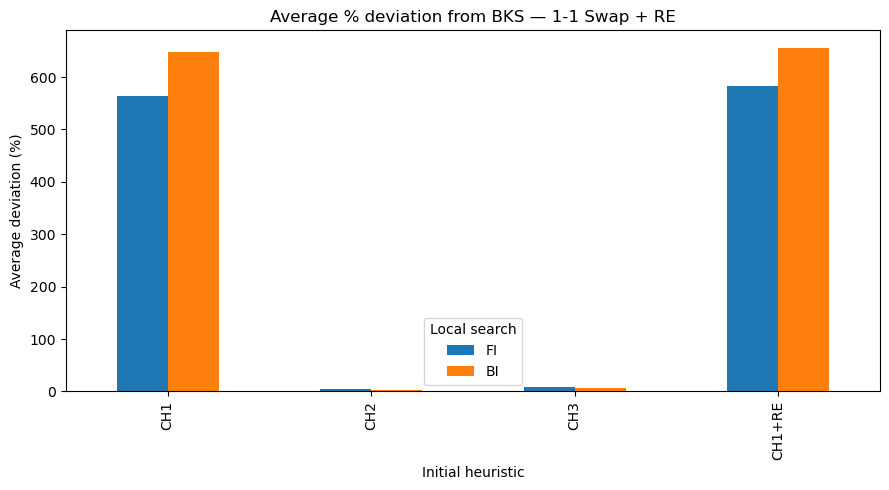

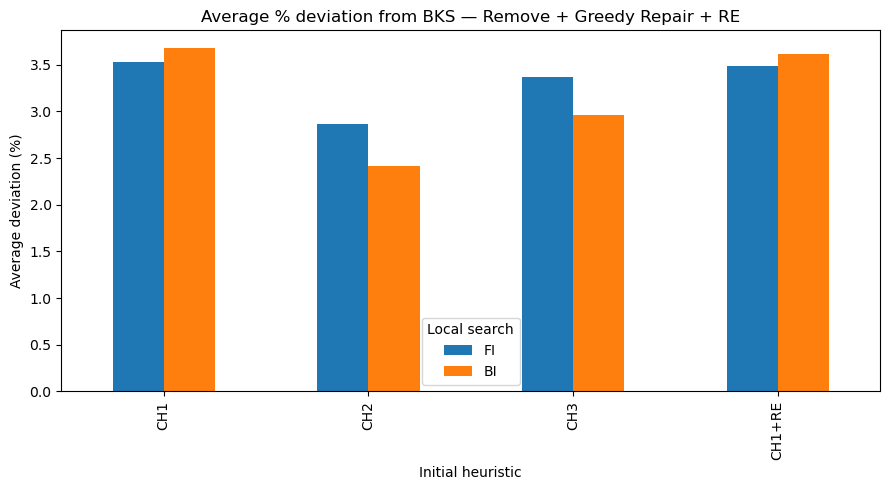

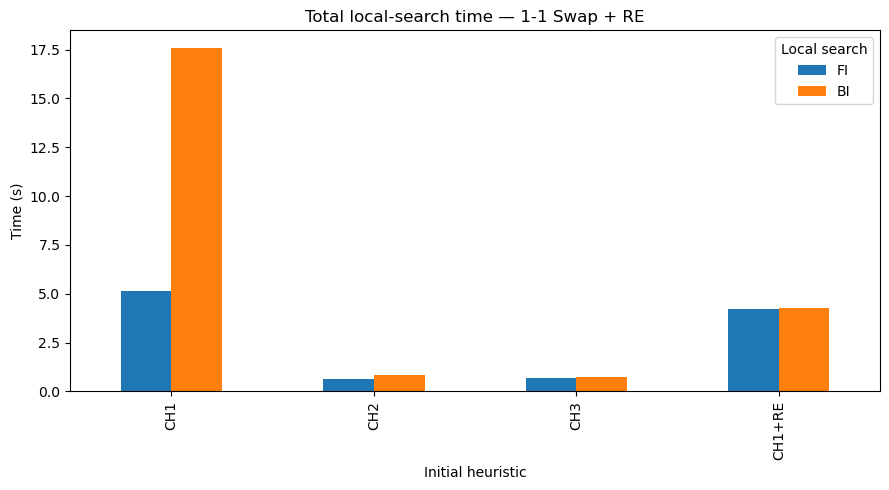

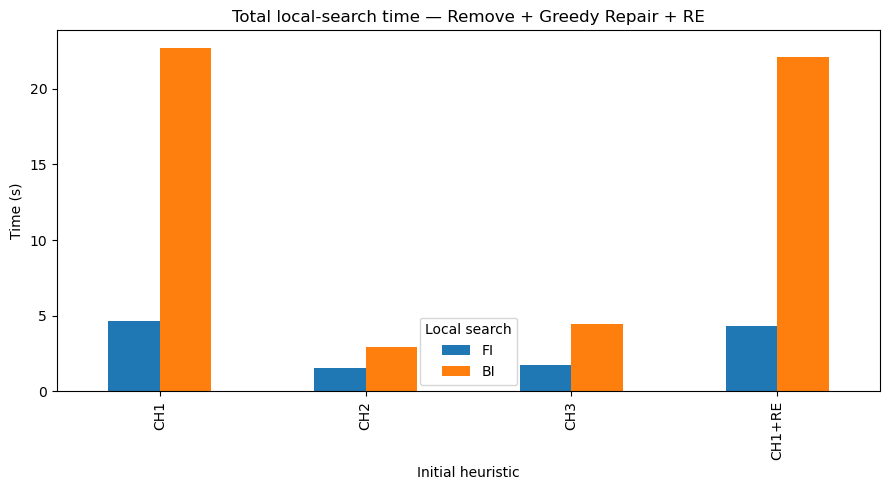

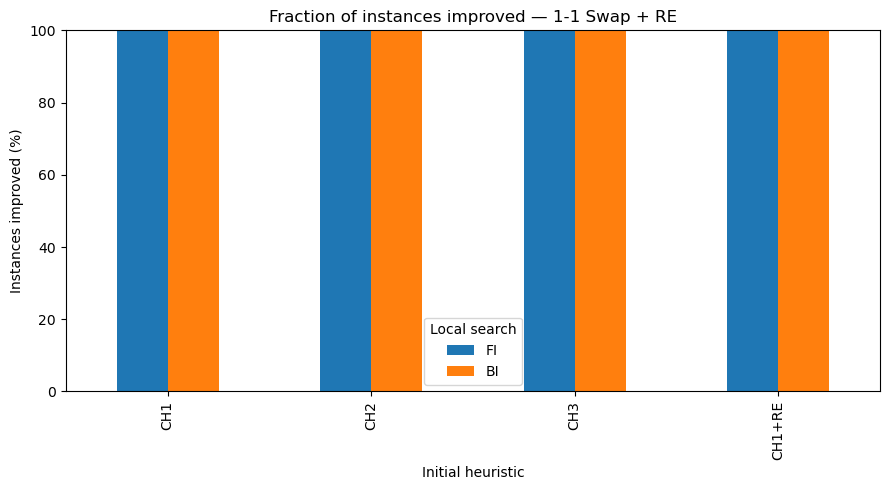

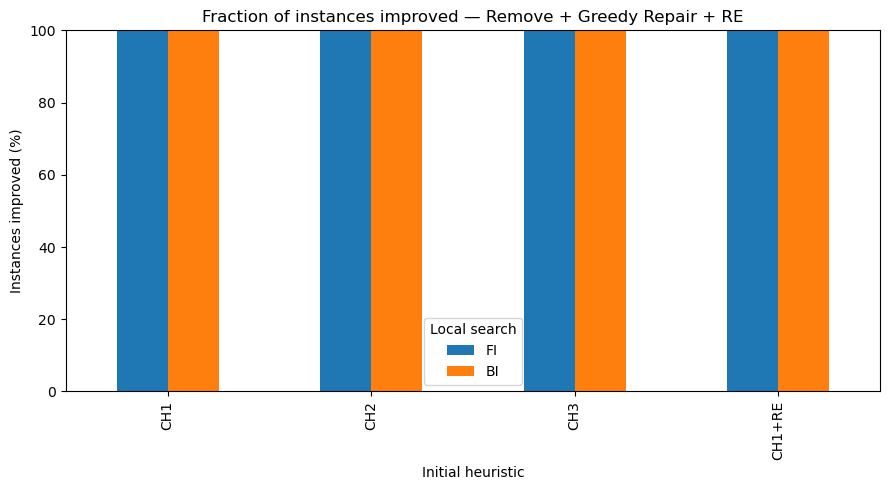

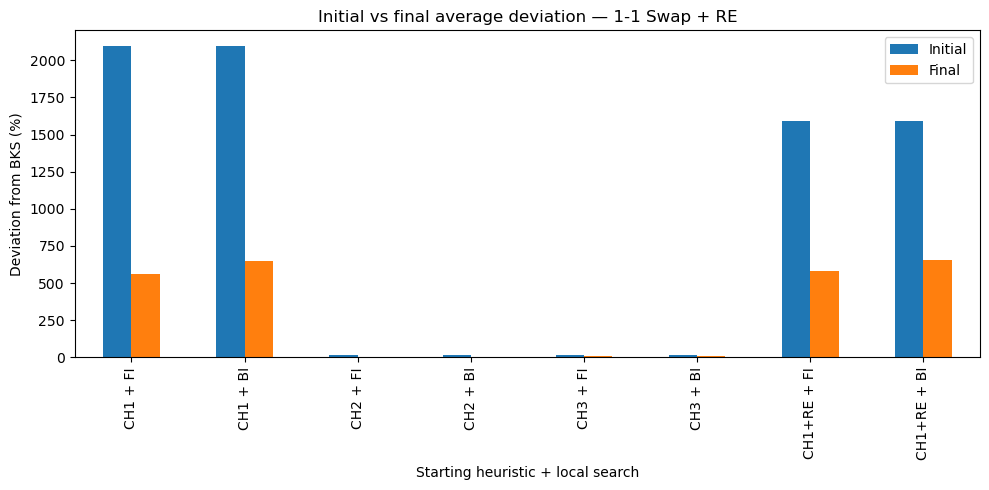

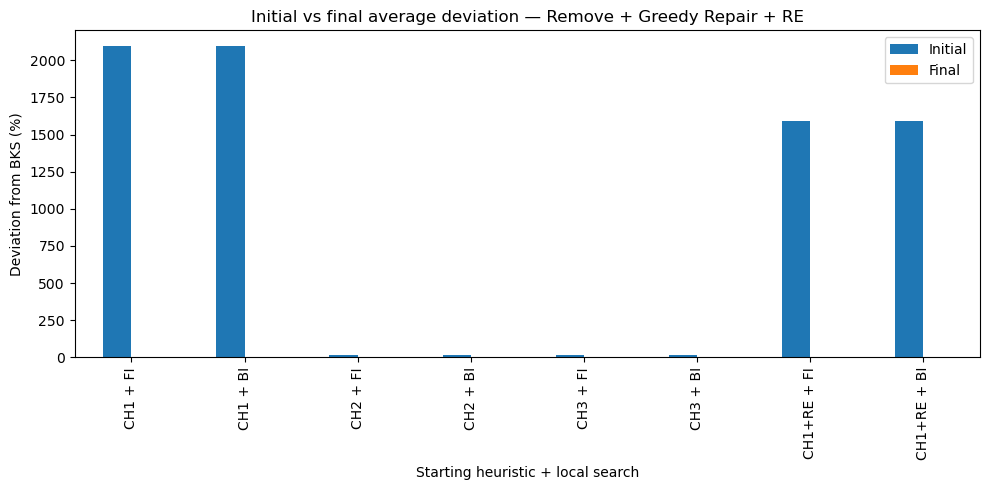

FI vs BI comparison table


,Neighborhood,Start_Heuristic,LS_Method,Avg_Dev,Total_LS_Time,Avg_Moves
0,1-1 Swap + RE,CH1,FI,564.11%,5.163,74.2
1,1-1 Swap + RE,CH1,BI,648.57%,17.604,22.6
2,1-1 Swap + RE,CH2,FI,4.72%,0.615,4.2
3,1-1 Swap + RE,CH2,BI,2.48%,0.848,2.7
4,1-1 Swap + RE,CH3,FI,8.83%,0.702,5.0
5,1-1 Swap + RE,CH3,BI,6.98%,0.747,3.1
6,1-1 Swap + RE,CH1+RE,FI,583.05%,4.239,67.5
7,1-1 Swap + RE,CH1+RE,BI,656.27%,4.279,23.1
8,Remove + Greedy Repair + RE,CH1,FI,3.53%,4.682,55.5
9,Remove + Greedy Repair + RE,CH1,BI,3.68%,22.725,33.2


CH1 vs CH1+RE as starting points


,Neighborhood,LS_Method,Start_Heuristic,Avg_Init_Dev,Avg_Final_Dev,LS_Time,Fraction_Improved
0,1-1 Swap + RE,FI,CH1,2096.61%,564.11%,5.163,100.0%
1,1-1 Swap + RE,BI,CH1,2096.61%,648.57%,17.604,100.0%
2,1-1 Swap + RE,FI,CH1+RE,1592.64%,583.05%,4.239,100.0%
3,1-1 Swap + RE,BI,CH1+RE,1592.64%,656.27%,4.279,100.0%
4,Remove + Greedy Repair + RE,FI,CH1,2096.61%,3.53%,4.682,100.0%
5,Remove + Greedy Repair + RE,BI,CH1,2096.61%,3.68%,22.725,100.0%
6,Remove + Greedy Repair + RE,FI,CH1+RE,1592.64%,3.49%,4.298,100.0%
7,Remove + Greedy Repair + RE,BI,CH1+RE,1592.64%,3.61%,22.100,100.0%


In [32]:
if not df_detailed.empty:
    GROUP = ["Neighborhood", "Start_Heuristic", "LS_Method"]

    # ---------- 1. Average deviation ----------
    for neighborhood, d in df_detailed.groupby("Neighborhood", sort=False):
        pivot = d.groupby(["Start_Heuristic", "LS_Method"], sort=False)["Pct_Dev"].mean().unstack()
        ax = pivot.plot(kind="bar", figsize=(9, 5))
        ax.set_title(f"Average % deviation from BKS — {neighborhood}")
        ax.set_ylabel("Average deviation (%)")
        ax.set_xlabel("Initial heuristic")
        ax.legend(title="Local search")
        plt.tight_layout()
        plt.show()

    # ---------- 2. Total local-search time ----------
    for neighborhood, d in df_detailed.groupby("Neighborhood", sort=False):
        pivot = d.groupby(["Start_Heuristic", "LS_Method"], sort=False)["Time_s"].sum().unstack()
        ax = pivot.plot(kind="bar", figsize=(9, 5))
        ax.set_title(f"Total local-search time — {neighborhood}")
        ax.set_ylabel("Time (s)")
        ax.set_xlabel("Initial heuristic")
        ax.legend(title="Local search")
        plt.tight_layout()
        plt.show()

    # ---------- 3. Fraction improved ----------
    for neighborhood, d in df_detailed.groupby("Neighborhood", sort=False):
        pivot = (d.groupby(["Start_Heuristic", "LS_Method"], sort=False)["Improved"]
                 .mean().mul(100).unstack())
        ax = pivot.plot(kind="bar", figsize=(9, 5))
        ax.set_title(f"Fraction of instances improved — {neighborhood}")
        ax.set_ylabel("Instances improved (%)")
        ax.set_xlabel("Initial heuristic")
        ax.set_ylim(0, 100)
        ax.legend(title="Local search")
        plt.tight_layout()
        plt.show()

    # ---------- 4. Initial vs final quality ----------
    before_after = (
        df_detailed.groupby(GROUP, sort=False)
        .agg(Initial_Pct_Dev=("Init_Pct_Dev", "mean"), Final_Pct_Dev=("Pct_Dev", "mean"))
        .reset_index()
    )
    for neighborhood, d in before_after.groupby("Neighborhood", sort=False):
        d = d.copy()
        d["Start"] = d["Start_Heuristic"] + " + " + d["LS_Method"]
        d = d.set_index("Start")[["Initial_Pct_Dev", "Final_Pct_Dev"]]
        ax = d.plot(kind="bar", figsize=(10, 5))
        ax.set_title(f"Initial vs final average deviation — {neighborhood}")
        ax.set_ylabel("Deviation from BKS (%)")
        ax.set_xlabel("Starting heuristic + local search")
        ax.legend(["Initial", "Final"])
        plt.tight_layout()
        plt.show()

    # ---------- 5. FI vs BI table ----------
    fi_bi = (
        df_detailed.groupby(GROUP, sort=False)
        .agg(Avg_Dev=("Pct_Dev", "mean"), Total_LS_Time=("Time_s", "sum"),
             Avg_Moves=("Moves", "mean"))
        .reset_index()
    )
    print("FI vs BI comparison table")
    display(fi_bi.style.format({"Avg_Dev": "{:.2f}%", "Total_LS_Time": "{:.3f}", "Avg_Moves": "{:.1f}"}))

    # ---------- 6. CH1 vs CH1+RE (does RE before the local search matter?) ----------
    ch1 = (df_detailed[df_detailed["Start_Heuristic"].isin(["CH1", "CH1+RE"])]
           .groupby(["Neighborhood", "LS_Method", "Start_Heuristic"], sort=False)
           .agg(Avg_Init_Dev=("Init_Pct_Dev", "mean"), Avg_Final_Dev=("Pct_Dev", "mean"),
                LS_Time=("Time_s", "sum"), Fraction_Improved=("Improved", "mean"))
           .reset_index())
    print("CH1 vs CH1+RE as starting points")
    display(ch1.style.format({"Avg_Init_Dev": "{:.2f}%", "Avg_Final_Dev": "{:.2f}%",
                              "LS_Time": "{:.3f}", "Fraction_Improved": "{:.1%}"}))
else:
    print("No experiment data available to plot.")

## 12. Automatic interpretation for the presentation

The next cell produces concise, data-driven observations. These are deliberately generated from the actual experiment output rather than hard-coded claims.


In [33]:
def interpretation_text(df):
    if df.empty:
        return "No experiment data are available."

    lines = []
    for neighborhood in df["Neighborhood"].unique():
        d = df[df["Neighborhood"] == neighborhood]

        mean_quality = d.groupby("LS_Method")["Pct_Dev"].mean()
        mean_time = d.groupby("LS_Method")["Time_s"].sum()
        improved = d.groupby("LS_Method")["Improved"].mean()

        best_method = mean_quality.idxmin()
        fastest_method = mean_time.idxmin()

        lines.append(
            f"• {neighborhood}: {best_method} has the lower overall average "
            f"deviation ({mean_quality[best_method]:.2f}%), while {fastest_method} "
            f"uses less total local-search time."
        )

        for method in ["FI", "BI"]:
            if method in mean_quality.index:
                lines.append(
                    f"  {method}: average deviation = {mean_quality[method]:.2f}%, "
                    f"total time = {mean_time[method]:.3f}s, "
                    f"fraction improved = {100*improved[method]:.1f}%."
                )

    # Starting-solution effect
    start_quality = (
        df.groupby("Start_Heuristic")["Pct_Dev"].mean().sort_values()
    )
    if len(start_quality):
        lines.append(
            f"• Across all local-search configurations, {start_quality.index[0]} "
            f"has the best average final deviation ({start_quality.iloc[0]:.2f}%), "
            f"whereas {start_quality.index[-1]} has the highest "
            f"({start_quality.iloc[-1]:.2f}%)."
        )

    # Neighborhood comparison
    neighborhood_quality = df.groupby("Neighborhood")["Pct_Dev"].mean().sort_values()
    neighborhood_time = df.groupby("Neighborhood")["Time_s"].sum()
    if len(neighborhood_quality) > 1:
        best_n = neighborhood_quality.index[0]
        lines.append(
            f"• Neighborhood comparison: {best_n} gives the lowest overall "
            f"average deviation ({neighborhood_quality.iloc[0]:.2f}%). "
            f"Total measured local-search time is "
            f"{neighborhood_time[best_n]:.3f}s for that neighborhood."
        )

    return "\n".join(lines)


print(interpretation_text(df_detailed))


• 1-1 Swap + RE: FI has the lower overall average deviation (290.18%), while FI uses less total local-search time.
  FI: average deviation = 290.18%, total time = 10.719s, fraction improved = 100.0%.
  BI: average deviation = 328.58%, total time = 23.480s, fraction improved = 100.0%.
• Remove + Greedy Repair + RE: BI has the lower overall average deviation (3.17%), while FI uses less total local-search time.
  FI: average deviation = 3.31%, total time = 12.245s, fraction improved = 100.0%.
  BI: average deviation = 3.17%, total time = 52.270s, fraction improved = 100.0%.
• Across all local-search configurations, CH2 has the best average final deviation (3.12%), whereas CH1+RE has the highest (311.60%).
• Neighborhood comparison: Remove + Greedy Repair + RE gives the lowest overall average deviation (3.24%). Total measured local-search time is 64.515s for that neighborhood.


                   Neighborhood Start_Heuristic LS_Method  Avg_Init_Dev  \
0                 1-1 Swap + RE             CH1        FI      2096.611   
1                 1-1 Swap + RE             CH1        BI      2096.611   
2                 1-1 Swap + RE             CH2        FI        13.623   
3                 1-1 Swap + RE             CH2        BI        13.623   
4                 1-1 Swap + RE             CH3        FI        15.821   
5                 1-1 Swap + RE             CH3        BI        15.821   
6                 1-1 Swap + RE          CH1+RE        FI      1592.642   
7                 1-1 Swap + RE          CH1+RE        BI      1592.642   
8   Remove + Greedy Repair + RE             CH1        FI      2096.611   
9   Remove + Greedy Repair + RE             CH1        BI      2096.611   
10  Remove + Greedy Repair + RE             CH2        FI        13.623   
11  Remove + Greedy Repair + RE             CH2        BI        13.623   
12  Remove + Greedy Repai

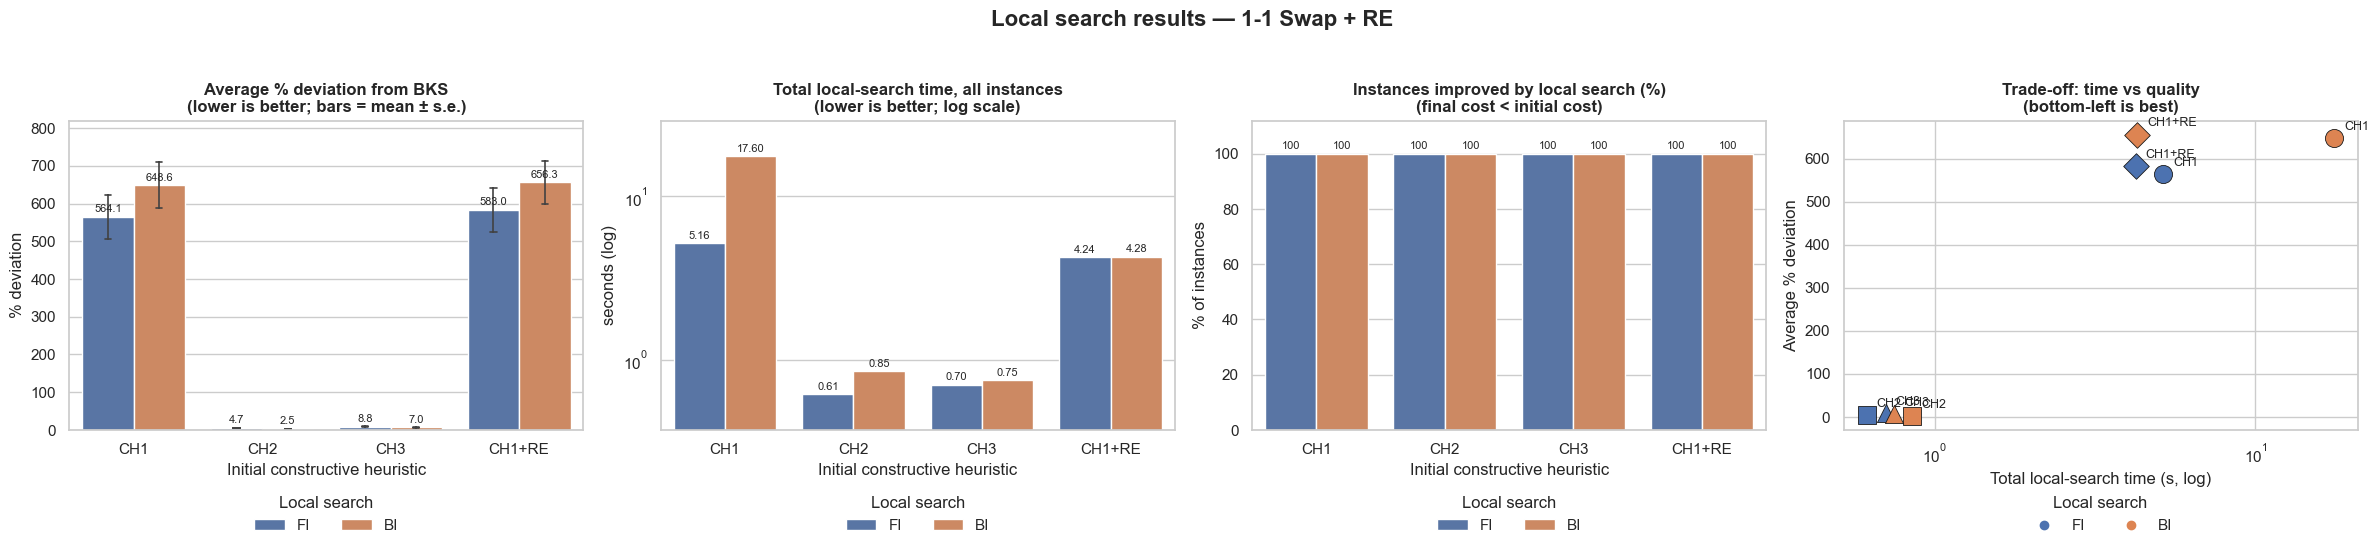

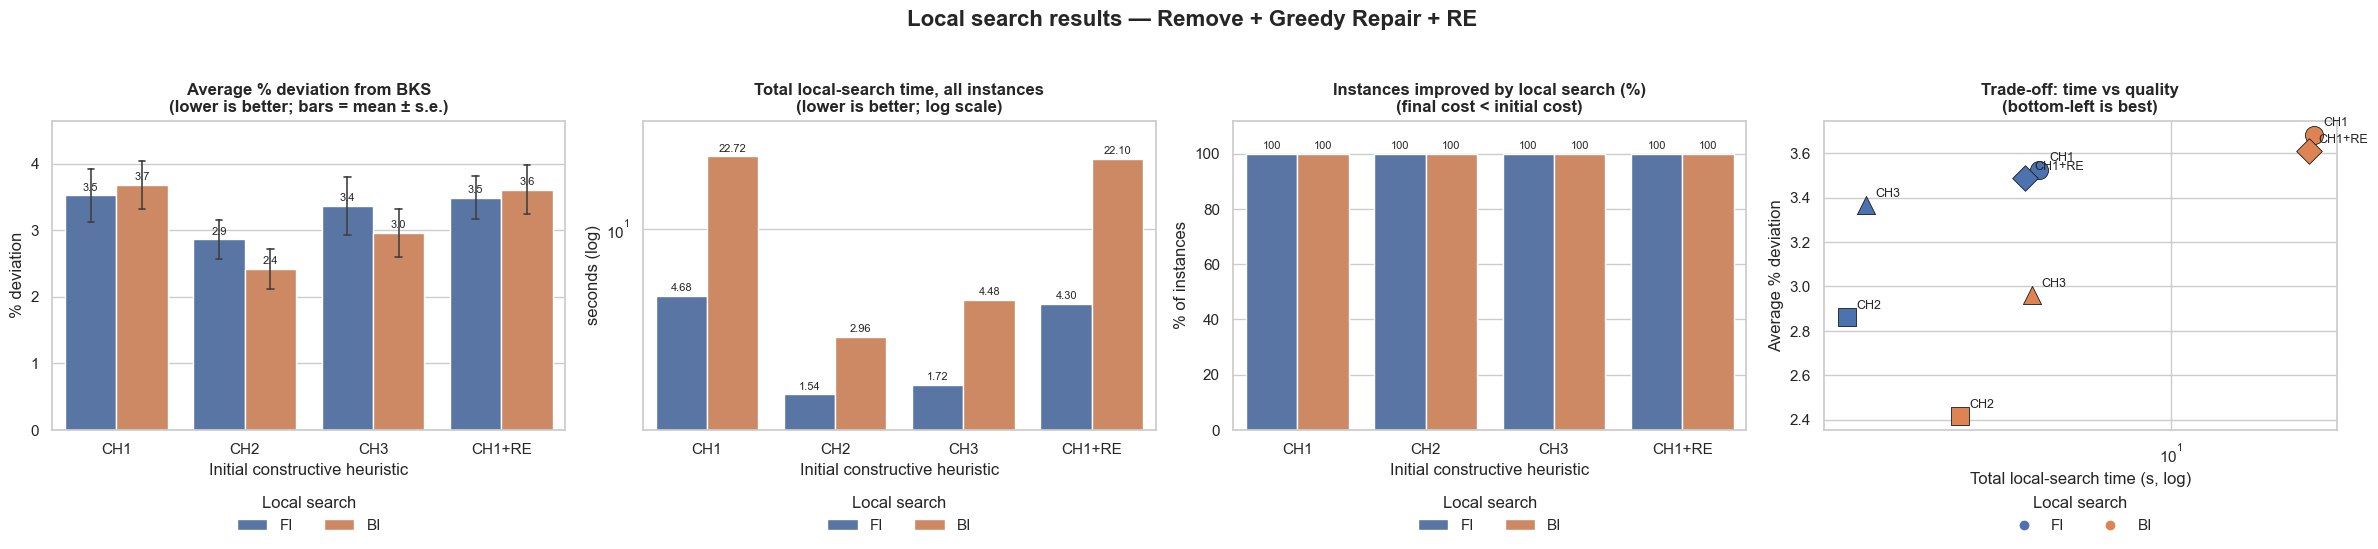

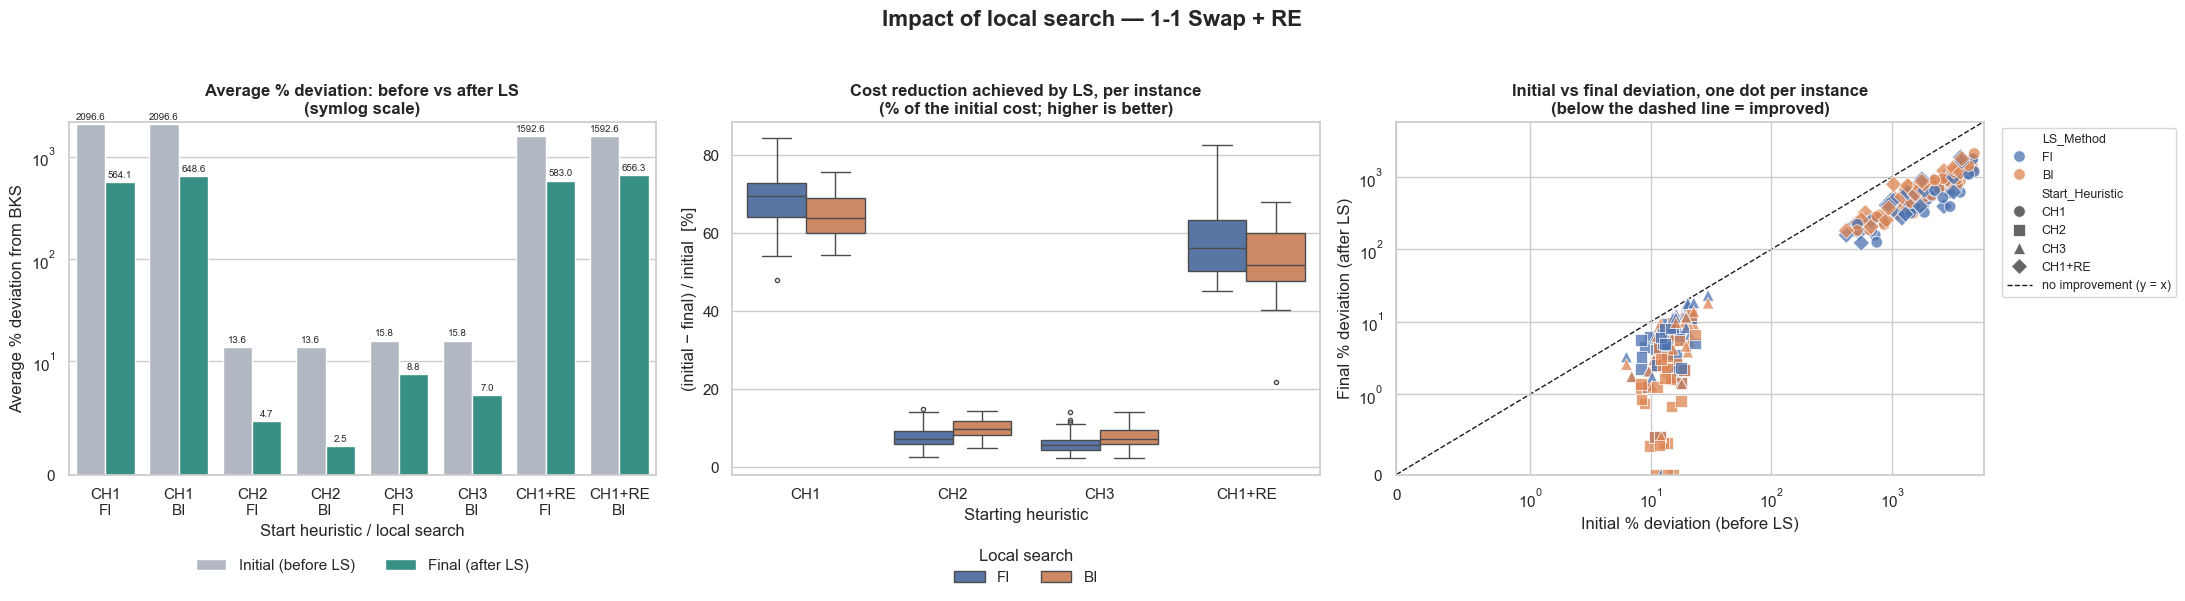

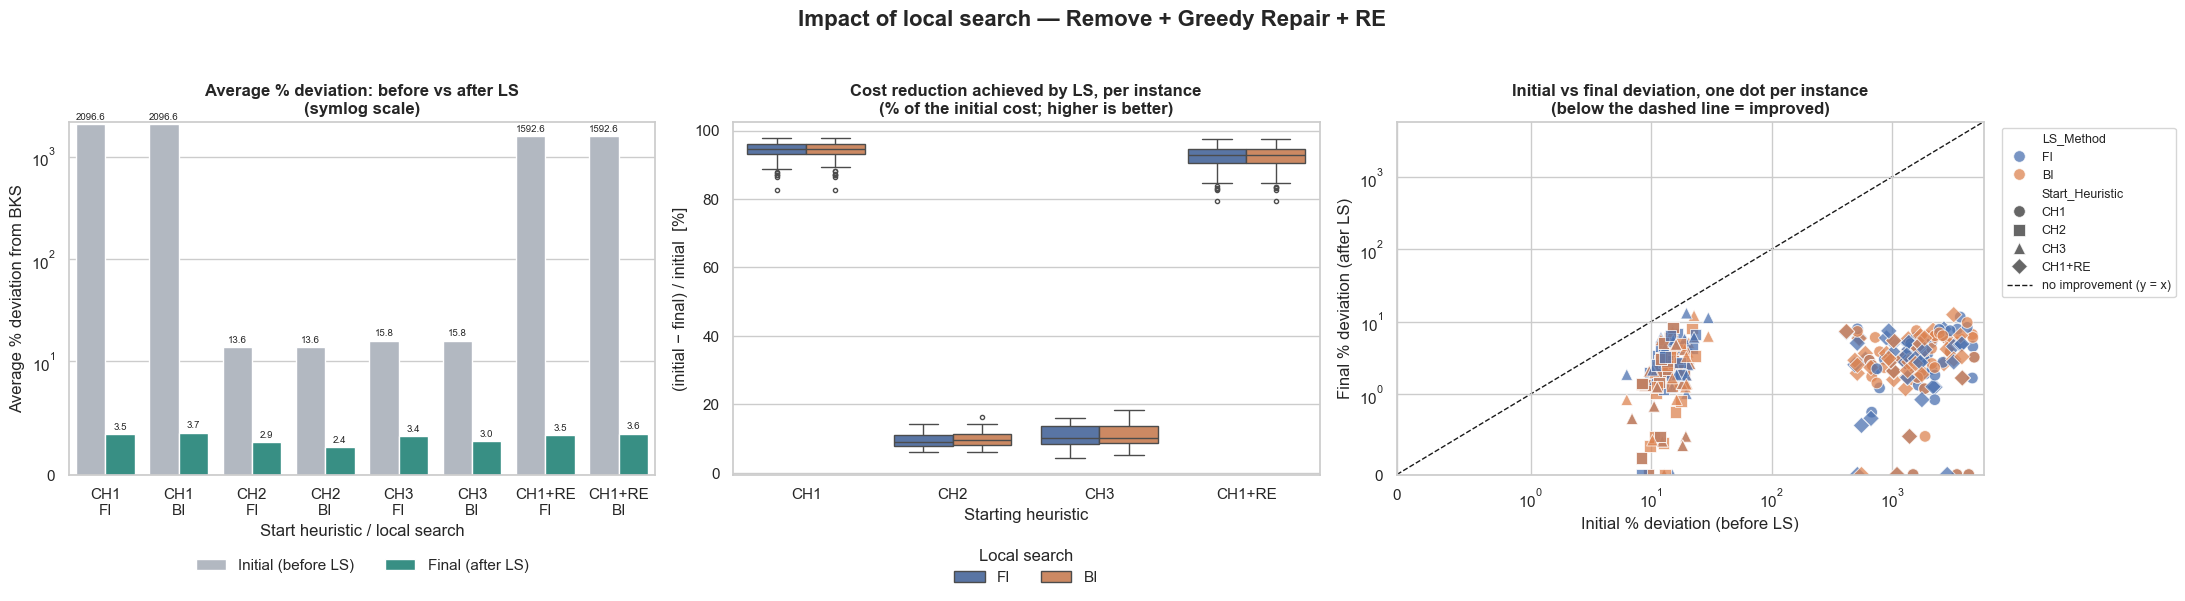

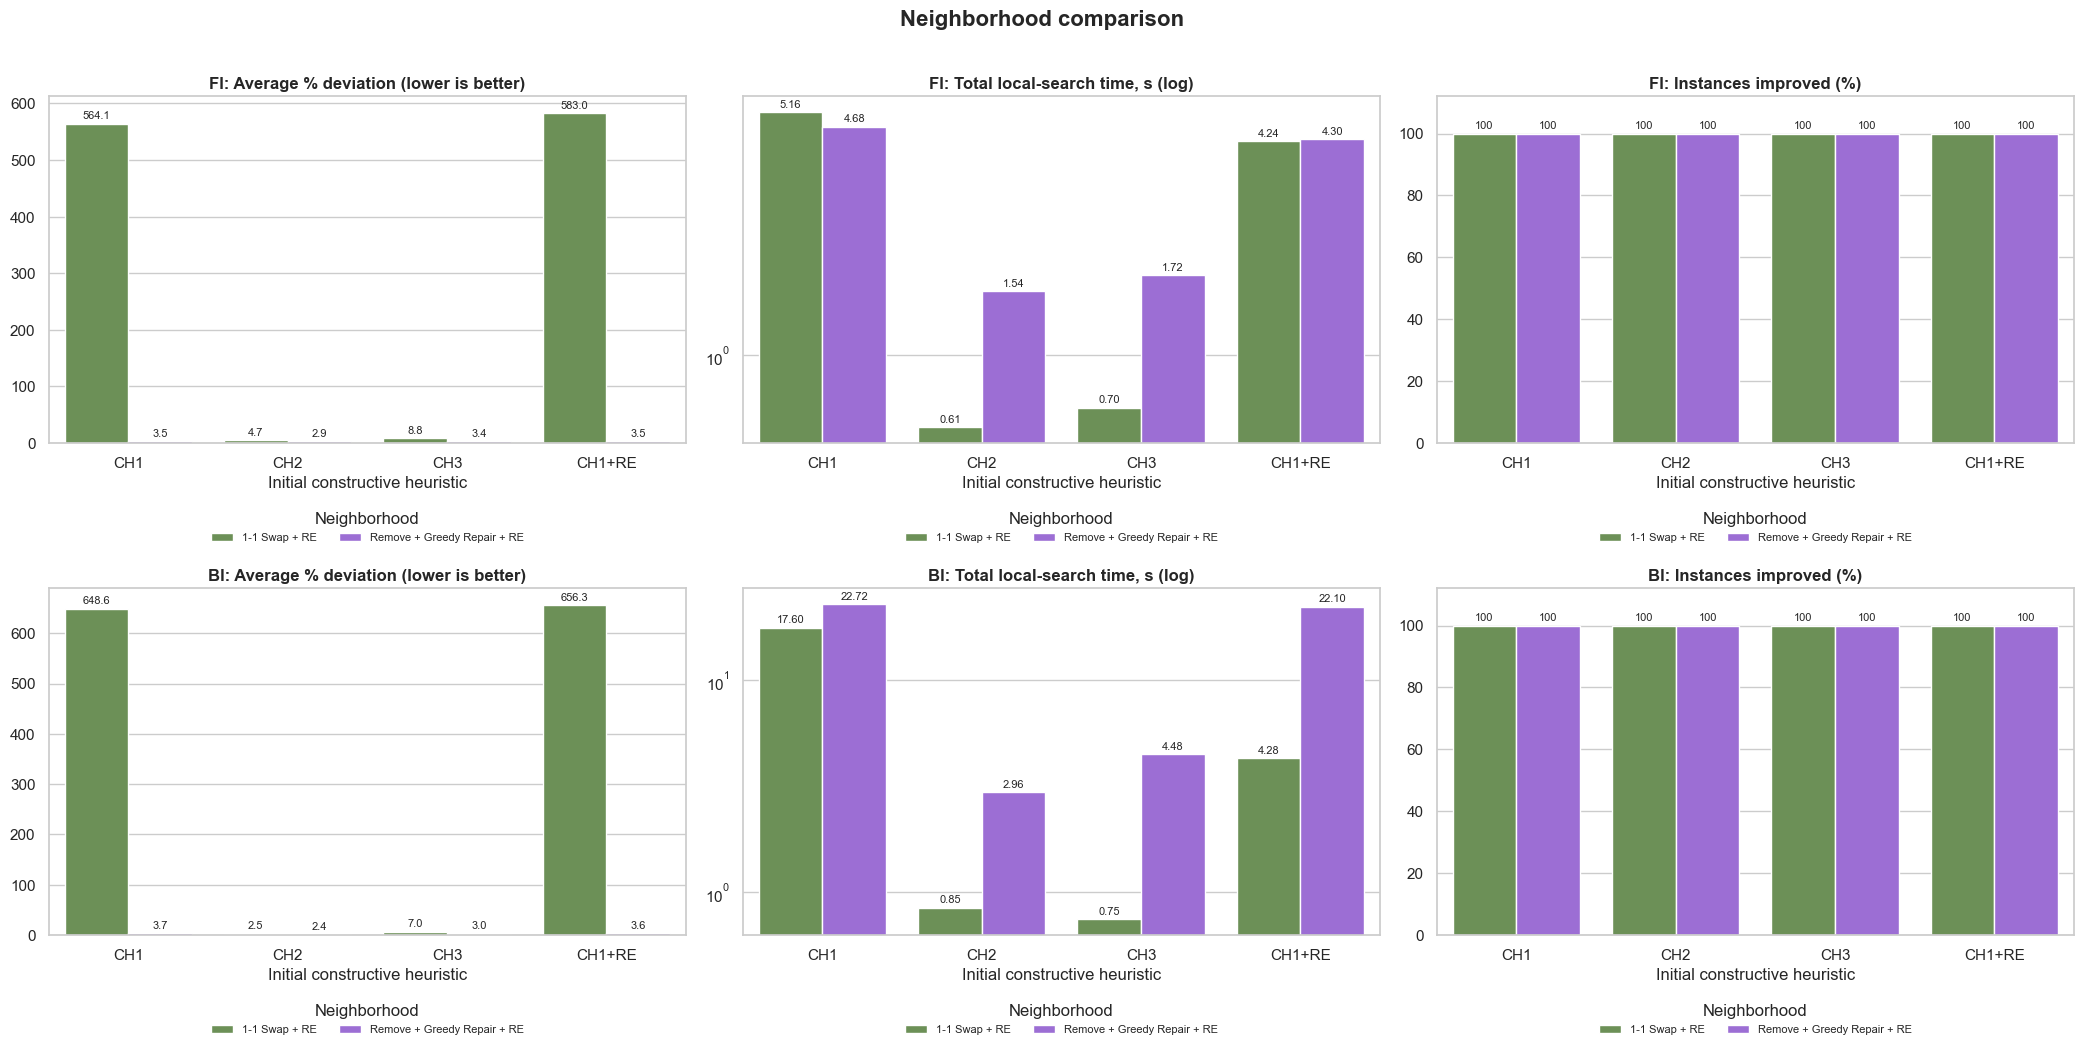

In [34]:
# %% ============ Setup: load results and build summary table ============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.container import BarContainer

CSV = "scp_local_search_results.csv"
SAVE_FIGS = True                      # saves PNGs (dpi 200) for the presentation

df = pd.read_csv(CSV)
if "Init_Pct_Dev" not in df:
    df["Init_Pct_Dev"] = 100.0 * (df["Init_Cost"] - df["BKS"]) / df["BKS"]
df["Improved"] = df["Improved"].astype(bool)
df["Rel_Improvement"] = 100.0 * (df["Init_Cost"] - df["Final_Cost"]) / df["Init_Cost"]  # % of cost removed by LS

START_ORDER  = [s for s in ["CH1", "CH2", "CH3", "CH1+RE"] if s in set(df["Start_Heuristic"])]
METHOD_ORDER = [m for m in ["FI", "BI"] if m in set(df["LS_Method"])]
NBH_ORDER    = list(dict.fromkeys(df["Neighborhood"]))        # order of appearance
METHOD_PAL   = {"FI": "#4C72B0", "BI": "#DD8452"}
STAGE_PAL    = {"Initial (before LS)": "#B0B7C3", "Final (after LS)": "#2A9D8F"}
MARKERS      = dict(zip(START_ORDER, ["o", "s", "^", "D"]))

sns.set_theme(style="whitegrid", font_scale=1.0)

# One row per (neighborhood, start, method) = the 16 experiments
summ = (df.groupby(["Neighborhood", "Start_Heuristic", "LS_Method"], sort=False)
          .agg(Avg_Init_Dev=("Init_Pct_Dev", "mean"),
               Avg_Dev=("Pct_Dev", "mean"),
               LS_Time=("Time_s", "sum"),
               Constr_Time=("Constr_Time_s", "sum") if "Constr_Time_s" in df else ("Time_s", lambda s: 0.0),
               Frac_Improved=("Improved", lambda s: 100.0 * s.mean()),
               Avg_Moves=("Moves", "mean"))
          .reset_index())
summ["Total_Time"] = summ["LS_Time"] + summ["Constr_Time"]
display(summ.round(3)) if "display" in globals() else print(summ.round(3))


def label_bars(ax, fmt="%.1f", size=8):
    for c in ax.containers:
        if isinstance(c, BarContainer):
            ax.bar_label(c, fmt=fmt, padding=2, fontsize=size)


def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(f"fig_{name}.png", dpi=200, bbox_inches="tight")


def slug(s):
    return "".join(ch if ch.isalnum() else "_" for ch in s).strip("_").lower()


# %% ============ Figure set 1 (per neighborhood): the 3 required measures + trade-off ============
for nbh in NBH_ORDER:
    d  = df[df["Neighborhood"] == nbh]
    sm = summ[summ["Neighborhood"] == nbh]
    fig, axes = plt.subplots(1, 4, figsize=(24, 5.5))
    fig.suptitle(f"Local search results — {nbh}", fontsize=16, fontweight="bold", y=1.03)

    # (a) Average % deviation from BKS (mean ± standard error over instances)
    sns.barplot(data=d, x="Start_Heuristic", y="Pct_Dev", hue="LS_Method",
                order=START_ORDER, hue_order=METHOD_ORDER, palette=METHOD_PAL,
                errorbar="se", capsize=0.1, err_kws={"linewidth": 1.2}, ax=axes[0])
    label_bars(axes[0], "%.1f")
    axes[0].set_title("Average % deviation from BKS\n(lower is better; bars = mean ± s.e.)", fontweight="bold")
    axes[0].set_xlabel("Initial constructive heuristic"); axes[0].set_ylabel("% deviation")

    # (b) Total local-search time over all instances (log scale: FI and BI differ by orders of magnitude)
    sns.barplot(data=sm, x="Start_Heuristic", y="LS_Time", hue="LS_Method",
                order=START_ORDER, hue_order=METHOD_ORDER, palette=METHOD_PAL, ax=axes[1])
    axes[1].set_yscale("log"); label_bars(axes[1], "%.2f")
    axes[1].set_title("Total local-search time, all instances\n(lower is better; log scale)", fontweight="bold")
    axes[1].set_xlabel("Initial constructive heuristic"); axes[1].set_ylabel("seconds (log)")

    # (c) Fraction of instances that profit from local search
    sns.barplot(data=sm, x="Start_Heuristic", y="Frac_Improved", hue="LS_Method",
                order=START_ORDER, hue_order=METHOD_ORDER, palette=METHOD_PAL, ax=axes[2])
    label_bars(axes[2], "%.0f")
    axes[2].set_ylim(0, 112)
    axes[2].set_title("Instances improved by local search (%)\n(final cost < initial cost)", fontweight="bold")
    axes[2].set_xlabel("Initial constructive heuristic"); axes[2].set_ylabel("% of instances")

    # (d) Time vs quality trade-off: one point per experiment
    for _, r in sm.iterrows():
        axes[3].scatter(r["LS_Time"], r["Avg_Dev"], s=170, marker=MARKERS[r["Start_Heuristic"]],
                        color=METHOD_PAL[r["LS_Method"]], edgecolor="k", linewidth=0.6, zorder=3)
        axes[3].annotate(r["Start_Heuristic"], (r["LS_Time"], r["Avg_Dev"]),
                         textcoords="offset points", xytext=(7, 6), fontsize=9)
    axes[3].set_xscale("log")
    axes[3].set_title("Trade-off: time vs quality\n(bottom-left is best)", fontweight="bold")
    axes[3].set_xlabel("Total local-search time (s, log)"); axes[3].set_ylabel("Average % deviation")
    handles = [plt.Line2D([], [], marker="o", ls="", color=METHOD_PAL[m], label=m) for m in METHOD_ORDER]
    axes[3].legend(handles=handles, title="Local search", ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False)

    for ax in axes[:3]:                               # legends below the plots so they never hide bars
        ax.margins(y=0.15)
        ax.legend(title="Local search", ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False)
    plt.tight_layout(); save(fig, f"required_{slug(nbh)}"); plt.show()


# %% ============ Figure set 2 (per neighborhood): impact of the local search ============
for nbh in NBH_ORDER:
    d  = df[df["Neighborhood"] == nbh]
    sm = summ[summ["Neighborhood"] == nbh].copy()
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    fig.suptitle(f"Impact of local search — {nbh}", fontsize=16, fontweight="bold", y=1.03)

    # (a) Average deviation before vs after, one pair of bars per start+method
    sm["Algorithm"] = sm["Start_Heuristic"] + "\n" + sm["LS_Method"]
    order = [f"{s}\n{m}" for s in START_ORDER for m in METHOD_ORDER]
    melt = sm.melt(id_vars="Algorithm", value_vars=["Avg_Init_Dev", "Avg_Dev"],
                   var_name="Stage", value_name="Deviation")
    melt["Stage"] = melt["Stage"].map({"Avg_Init_Dev": "Initial (before LS)", "Avg_Dev": "Final (after LS)"})
    sns.barplot(data=melt, x="Algorithm", y="Deviation", hue="Stage", order=order,
                hue_order=list(STAGE_PAL), palette=STAGE_PAL, ax=axes[0])
    axes[0].set_yscale("symlog", linthresh=10)    # CH1 starts are far worse than CH2/CH3
    label_bars(axes[0], "%.1f", 7)
    axes[0].set_title("Average % deviation: before vs after LS\n(symlog scale)", fontweight="bold")
    axes[0].set_xlabel("Start heuristic / local search"); axes[0].set_ylabel("Average % deviation from BKS")
    axes[0].legend(title="", ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.2), frameon=False)

    # (b) Relative cost reduction achieved by LS, per instance
    sns.boxplot(data=d, x="Start_Heuristic", y="Rel_Improvement", hue="LS_Method",
                order=START_ORDER, hue_order=METHOD_ORDER, palette=METHOD_PAL, fliersize=3, ax=axes[1])
    axes[1].set_title("Cost reduction achieved by LS, per instance\n(% of the initial cost; higher is better)", fontweight="bold")
    axes[1].set_xlabel("Starting heuristic"); axes[1].set_ylabel("(initial − final) / initial  [%]")
    axes[1].legend(title="Local search", ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False)

    # (c) Initial vs final deviation, one dot per instance, with the y = x reference line
    sns.scatterplot(data=d, x="Init_Pct_Dev", y="Pct_Dev", hue="LS_Method", style="Start_Heuristic",
                    hue_order=METHOD_ORDER, palette=METHOD_PAL, style_order=START_ORDER,
                    markers=MARKERS, alpha=0.75, s=70, ax=axes[2])
    hi = max(d["Init_Pct_Dev"].max(), d["Pct_Dev"].max()) * 1.2
    axes[2].plot([0, hi], [0, hi], "k--", lw=1, zorder=0, label="no improvement (y = x)")
    axes[2].set_xscale("symlog", linthresh=1); axes[2].set_yscale("symlog", linthresh=1)
    axes[2].set_xlim(0, hi); axes[2].set_ylim(0, hi)
    axes[2].set_title("Initial vs final deviation, one dot per instance\n(below the dashed line = improved)", fontweight="bold")
    axes[2].set_xlabel("Initial % deviation (before LS)"); axes[2].set_ylabel("Final % deviation (after LS)")
    axes[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)

    plt.tight_layout(); save(fig, f"impact_{slug(nbh)}"); plt.show()


# %% ============ Figure 3: neighborhood comparison (all 16 combinations side by side) ============
if len(NBH_ORDER) > 1:
    NBH_PAL = dict(zip(NBH_ORDER, ["#6A994E", "#9B5DE5", "#F4A261", "#E76F51"]))
    fig, axes = plt.subplots(len(METHOD_ORDER), 3, figsize=(21, 5.2 * len(METHOD_ORDER)), squeeze=False)
    fig.suptitle("Neighborhood comparison", fontsize=16, fontweight="bold", y=1.01)
    for r, meth in enumerate(METHOD_ORDER):
        sm = summ[summ["LS_Method"] == meth]
        specs = [("Avg_Dev", "Average % deviation (lower is better)", False, "%.1f"),
                 ("LS_Time", "Total local-search time, s (log)", True, "%.2f"),
                 ("Frac_Improved", "Instances improved (%)", False, "%.0f")]
        for c, (col, title, log, fmt) in enumerate(specs):
            ax = axes[r, c]
            sns.barplot(data=sm, x="Start_Heuristic", y=col, hue="Neighborhood", order=START_ORDER,
                        hue_order=NBH_ORDER, palette=NBH_PAL, ax=ax)
            if log: ax.set_yscale("log")
            label_bars(ax, fmt, 8)
            ax.set_title(f"{meth}: {title}", fontweight="bold")
            ax.set_xlabel("Initial constructive heuristic"); ax.set_ylabel("")
            if col == "Frac_Improved": ax.set_ylim(0, 112)
            ax.legend(title="Neighborhood", fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.17), frameon=False)
    plt.tight_layout(); save(fig, "neighborhood_comparison"); plt.show()